Download Data

In [57]:
import yfinance as yf

ticker_symbol = '^IXIC'
start_date = '2016-01-01'

nasdaq_data = yf.download(ticker_symbol, start=start_date)

print("NASDAQ Composite Index data downloaded successfully.")
print(nasdaq_data.head())

print('Missing values per column:')
display(nasdaq_data.isnull().sum())

print('\nTotal rows:', nasdaq_data.shape[0])
print('Total columns:', nasdaq_data.shape[1])



/tmp/ipython-input-275/2301481429.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  nasdaq_data = yf.download(ticker_symbol, start=start_date)
[*********************100%***********************]  1 of 1 completed


NASDAQ Composite Index data downloaded successfully.
Price             Close         High          Low         Open      Volume
Ticker            ^IXIC        ^IXIC        ^IXIC        ^IXIC       ^IXIC
Date                                                                      
2016-01-04  4903.089844  4903.089844  4846.979980  4897.649902  2218420000
2016-01-05  4891.430176  4926.729980  4872.740234  4917.839844  1927380000
2016-01-06  4835.759766  4866.040039  4804.689941  4813.759766  2168620000
2016-01-07  4689.430176  4788.020020  4688.169922  4736.399902  2552590000
2016-01-08  4643.629883  4742.569824  4637.850098  4722.020020  2288750000
Missing values per column:


,,0
Price,Ticker,
Close,^IXIC,0
High,^IXIC,0
Low,^IXIC,0
Open,^IXIC,0
Volume,^IXIC,0



Total rows: 2552
Total columns: 5


Model from Lecture

In [58]:
import pandas as pd
from prophet import Prophet


nasdaq_data.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in nasdaq_data.columns.values]


prophet_df = nasdaq_data[['Close_^IXIC']].copy()
prophet_df.columns = ['price']


train_size = int(len(prophet_df) * 0.8)
train = prophet_df.iloc[:train_size]
test = prophet_df.iloc[train_size:]

prophet_train = pd.DataFrame({
    'ds': train.index,
    'y': train['price'].values
  })

print("Fitting Prophet model...")
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.05,
    seasonality_prior_scale=10.0
)

prophet_model.fit(prophet_train)

future = prophet_model.make_future_dataframe(periods=len(test), freq='D')

forecast = prophet_model.predict(future)

forecast.set_index('ds', inplace=True)

forecast_test = forecast.reindex(test.index).copy()

forecast_test = forecast_test.dropna()

Fitting Prophet model...


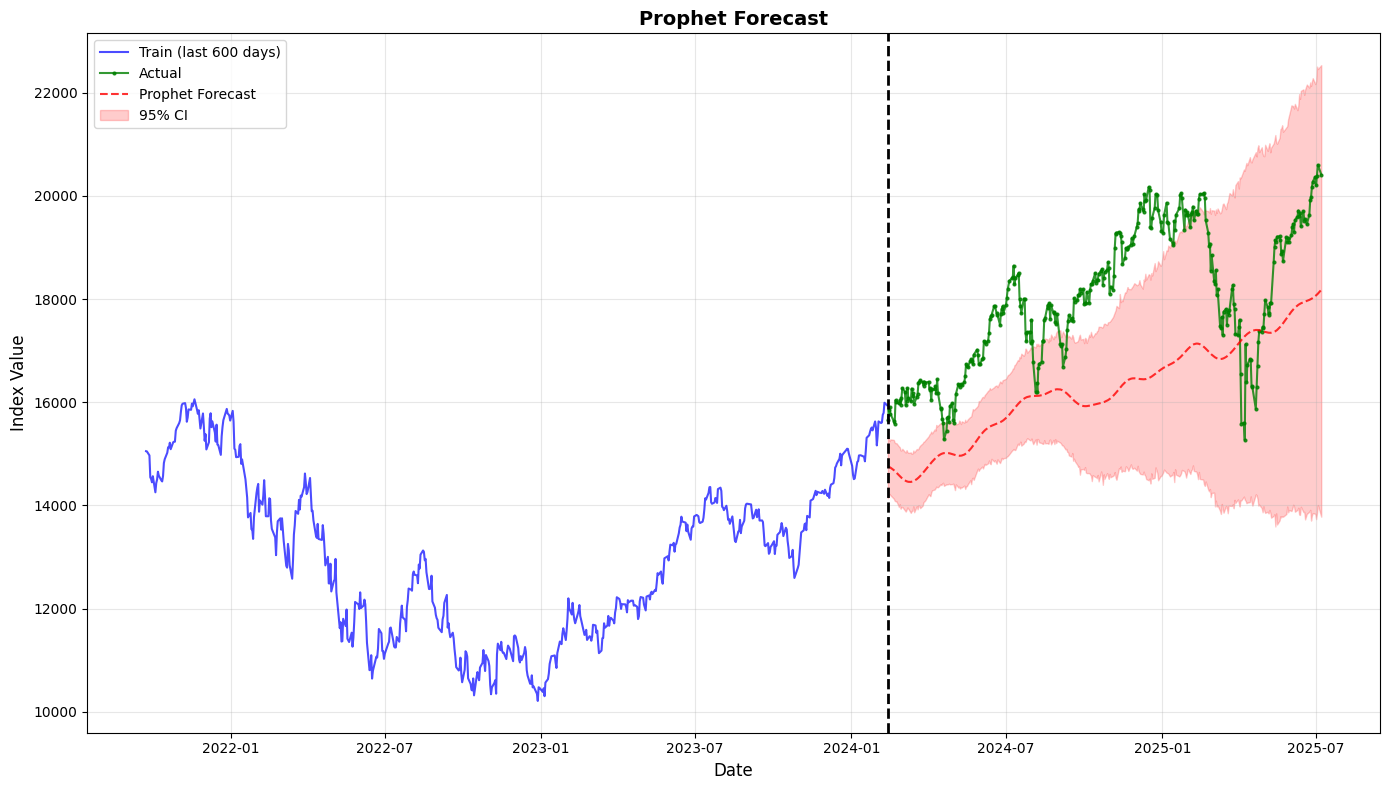

In [59]:
import matplotlib.pyplot as plt

split_date = test.index.min()

fig, ax = plt.subplots(1, 1, figsize=(14, 8))

ax.plot(train.index[-600:], train['price'][-600:], linewidth=1.5, alpha=0.7,
        color='blue', label='Train (last 600 days)')
aligned_test_plot = test.reindex(forecast_test.index).dropna()
ax.plot(aligned_test_plot.index, aligned_test_plot['price'], linewidth=1.5, alpha=0.8,
        color='green', label='Actual', marker='o', markersize=2)
ax.plot(forecast_test.index, forecast_test['yhat'], linewidth=1.5, alpha=0.8,
        color='red', linestyle='--', label='Prophet Forecast')
ax.fill_between(forecast_test.index,
                 forecast_test['yhat_lower'],
                 forecast_test['yhat_upper'],
                 alpha=0.2, color='red', label='95% CI')
ax.axvline(x=split_date, color='black', linestyle='--', linewidth=2)
ax.set_title('Prophet Forecast', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Index Value', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

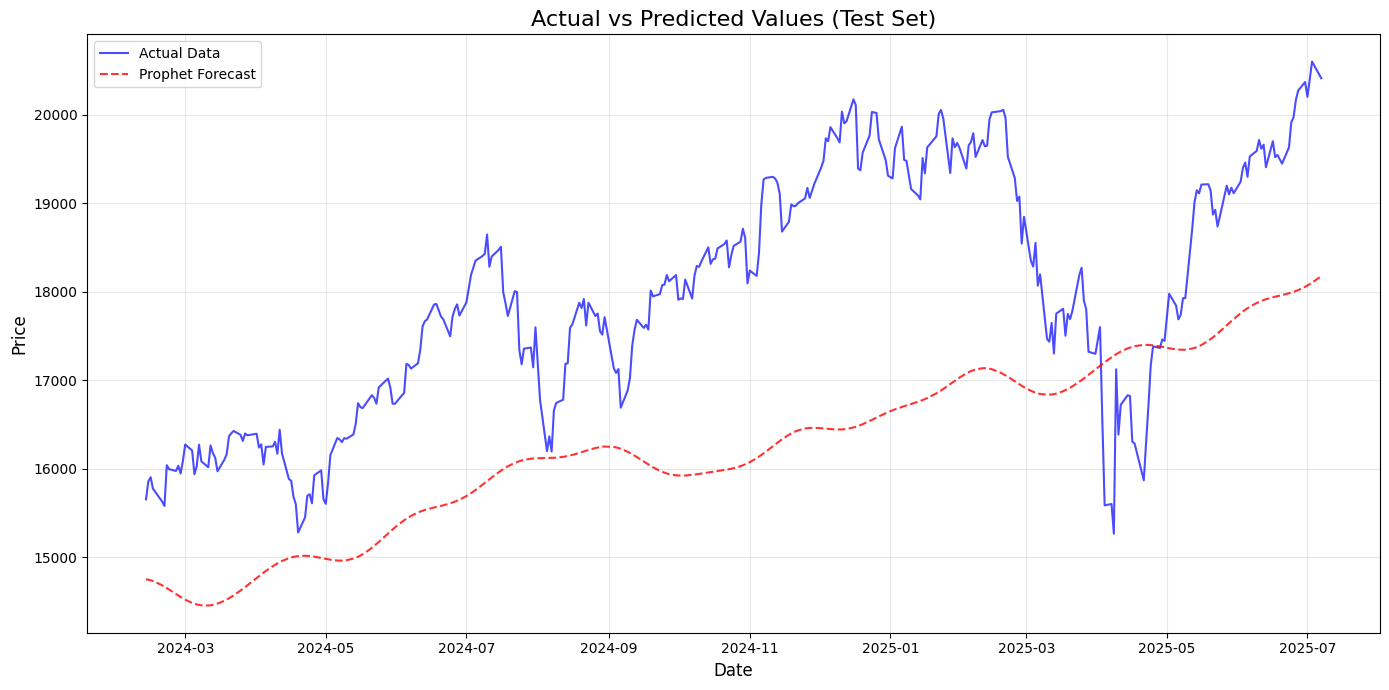

In [60]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np



if 'aligned_test' in locals() and 'aligned_forecast' in locals():
    comparison_df = pd.DataFrame({
        'Actual': aligned_test['price'],
        'Predicted': aligned_forecast['yhat'],
        'Difference': aligned_test['price'] - aligned_forecast['yhat'],
        'Error (%)': (np.abs(aligned_test['price'] - aligned_forecast['yhat']) / aligned_test['price']) * 100
    })

    plt.figure(figsize=(14, 7))

    plt.plot(comparison_df.index, comparison_df['Actual'],
             label='Actual Data', color='blue', alpha=0.7)

    plt.plot(comparison_df.index, comparison_df['Predicted'],
             label='Prophet Forecast', color='red', linestyle='--', alpha=0.8)

    plt.title('Actual vs Predicted Values (Test Set)', fontsize=16)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Price', fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("Necessary data (aligned_test, aligned_forecast) not found. Please run the model evaluation cells first.")

In [61]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np


aligned_test = test.reindex(forecast_test.index).dropna()
aligned_forecast = forecast_test.loc[aligned_test.index]

y_true = aligned_test['price']
y_pred = aligned_forecast['yhat']

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mape = mean_absolute_percentage_error(y_true, y_pred) * 100

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

Mean Absolute Error (MAE): 1773.76
Root Mean Squared Error (RMSE): 1948.44
Mean Absolute Percentage Error (MAPE): 9.72%


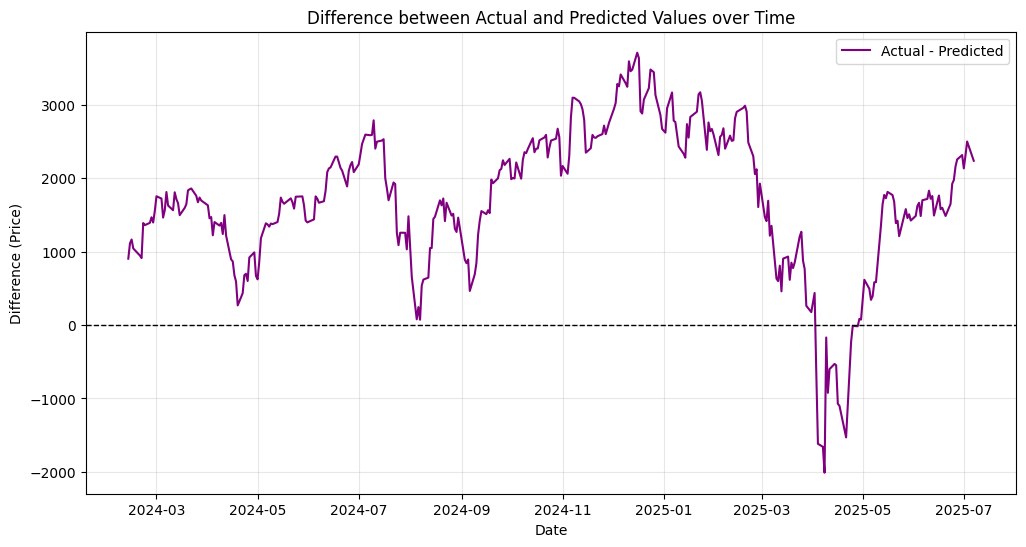

In [62]:
plt.figure(figsize=(12, 6))
plt.plot(comparison_df.index, comparison_df['Difference'], label='Actual - Predicted', color='purple')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title('Difference between Actual and Predicted Values over Time')
plt.xlabel('Date')
plt.ylabel('Difference (Price)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

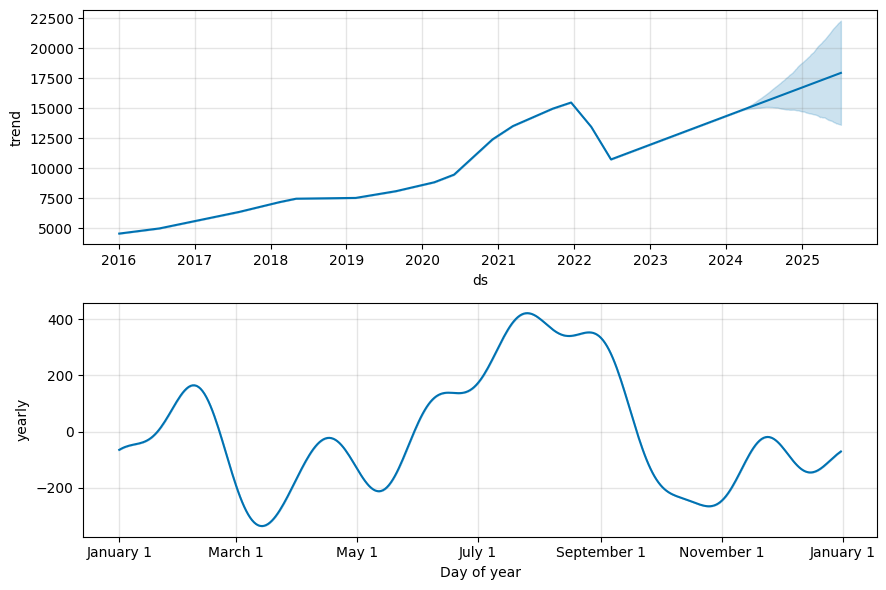

In [63]:
fig2 = prophet_model.plot_components(forecast.reset_index())
plt.show()

Next 5-day prediction

Data prepared for rolling forecast:


,ds,y
0,2016-01-04,4903.089844
1,2016-01-05,4891.430176
2,2016-01-06,4835.759766
3,2016-01-07,4689.430176
4,2016-01-08,4643.629883


Training Prophet model on full dataset...


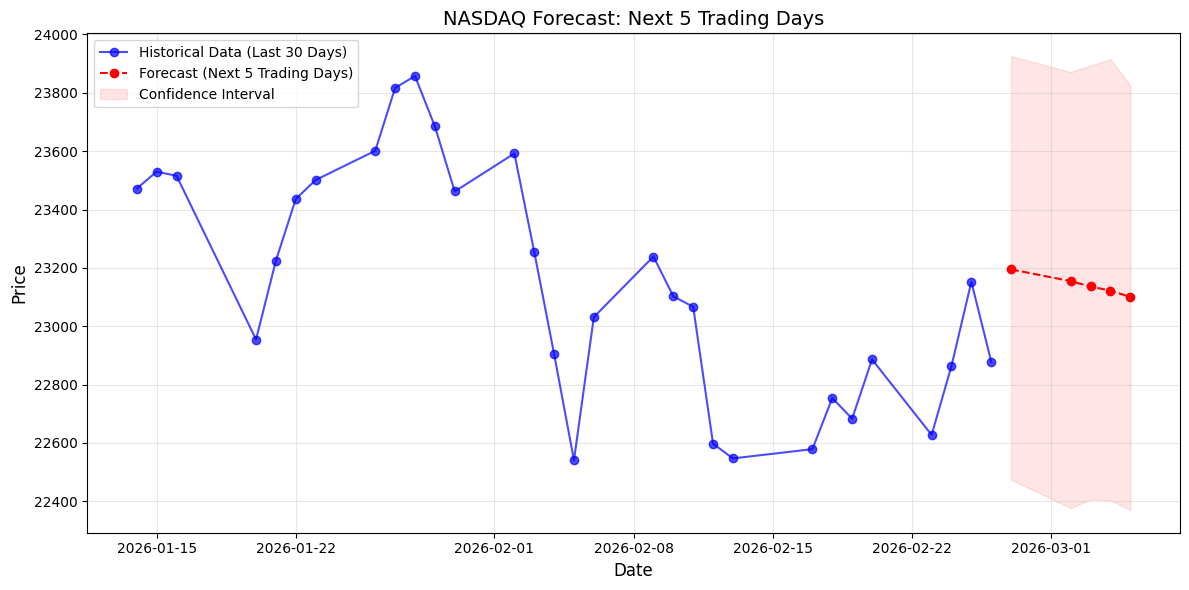

Forecasted values for the next 5 trading days:


,ds,yhat,yhat_lower,yhat_upper
2552,2026-02-27,23194.610585,22473.857718,23926.150588
2553,2026-03-02,23154.445194,22376.729472,23871.020891
2554,2026-03-03,23136.030763,22406.284433,23893.731525
2555,2026-03-04,23121.720997,22403.577503,23914.767612
2556,2026-03-05,23100.464308,22369.712901,23825.981094


In [64]:
from prophet import Prophet
import pandas as pd
import matplotlib.pyplot as plt


rolling_df = nasdaq_data[['Close_^IXIC']].copy()
rolling_df.reset_index(inplace=True)
rolling_df.columns = ['ds', 'y']

rolling_df['ds'] = pd.to_datetime(rolling_df['ds'])
rolling_df = rolling_df.sort_values('ds')

print("Data prepared for rolling forecast:")
display(rolling_df.head())

print("Training Prophet model on full dataset...")
full_model = Prophet(daily_seasonality=False, yearly_seasonality=True, weekly_seasonality=True)
full_model.fit(rolling_df)


future_days = full_model.make_future_dataframe(periods=5, freq='B')


forecast_future = full_model.predict(future_days)


last_actual_days = rolling_df.iloc[-30:].copy()
predicted_days = forecast_future.iloc[-5:].copy()


plt.figure(figsize=(12, 6))


plt.plot(last_actual_days['ds'], last_actual_days['y'],
         label='Historical Data (Last 30 Days)', marker='o', color='blue', alpha=0.7)


plt.plot(predicted_days['ds'], predicted_days['yhat'],
         label='Forecast (Next 5 Trading Days)', marker='o', linestyle='--', color='red')


plt.fill_between(predicted_days['ds'],
                 predicted_days['yhat_lower'],
                 predicted_days['yhat_upper'],
                 color='red', alpha=0.1, label='Confidence Interval')

plt.title('NASDAQ Forecast: Next 5 Trading Days', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


print("Forecasted values for the next 5 trading days:")
display(predicted_days[['ds', 'yhat', 'yhat_lower', 'yhat_upper']])

Rolling 5 Day Forecast

In [65]:
rolling_df = nasdaq_data[['Close_^IXIC']].copy()
rolling_df.reset_index(inplace=True)
rolling_df.columns = ['ds', 'y']

rolling_df['ds'] = pd.to_datetime(rolling_df['ds'])
rolling_df = rolling_df.sort_values('ds')

print("Data prepared for rolling forecast:")
display(rolling_df.head())

Data prepared for rolling forecast:


,ds,y
0,2016-01-04,4903.089844
1,2016-01-05,4891.430176
2,2016-01-06,4835.759766
3,2016-01-07,4689.430176
4,2016-01-08,4643.629883


In [66]:
from prophet import Prophet
import pandas as pd
import logging


logging.getLogger('cmdstanpy').setLevel(logging.WARNING)
logging.getLogger('prophet').setLevel(logging.WARNING)

window_size = 600
prediction_horizon = 5
forecasts = []


total_rows = len(rolling_df)

print(f"Starting rolling forecast with window_size={window_size}, horizon={prediction_horizon}...")



for i in range(0, total_rows - window_size, prediction_horizon):

    train_batch = rolling_df.iloc[i : i + window_size].copy()


    if i + window_size + prediction_horizon > total_rows:
        break


    m = Prophet(daily_seasonality=False, yearly_seasonality=True, weekly_seasonality=False)
    m.fit(train_batch)


    future = m.make_future_dataframe(periods=prediction_horizon)


    forecast = m.predict(future)


    forecast_segment = forecast.iloc[-prediction_horizon:][['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()

    forecasts.append(forecast_segment)

    if (i // prediction_horizon) % 20 == 0:
        print(f"Processed iteration starting at index {i}/{total_rows}")


if forecasts:
    rolling_forecast_results = pd.concat(forecasts, ignore_index=True)
    print("Rolling forecast completed.")
    display(rolling_forecast_results.head())
else:
    print("No forecasts were generated. Check data length and window size.")

Starting rolling forecast with window_size=600, horizon=5...
Processed iteration starting at index 0/2552
Processed iteration starting at index 100/2552
Processed iteration starting at index 200/2552
Processed iteration starting at index 300/2552
Processed iteration starting at index 400/2552
Processed iteration starting at index 500/2552
Processed iteration starting at index 600/2552
Processed iteration starting at index 700/2552
Processed iteration starting at index 800/2552
Processed iteration starting at index 900/2552
Processed iteration starting at index 1000/2552
Processed iteration starting at index 1100/2552
Processed iteration starting at index 1200/2552
Processed iteration starting at index 1300/2552
Processed iteration starting at index 1400/2552
Processed iteration starting at index 1500/2552
Processed iteration starting at index 1600/2552
Processed iteration starting at index 1700/2552
Processed iteration starting at index 1800/2552
Processed iteration starting at index 1

,ds,yhat,yhat_lower,yhat_upper
0,2018-05-22,7271.178345,7152.663749,7390.438746
1,2018-05-23,7276.100333,7155.586902,7399.892155
2,2018-05-24,7280.876244,7159.778962,7404.395020
3,2018-05-25,7285.431017,7151.955005,7410.822664
4,2018-05-26,7289.688926,7168.992333,7409.634564


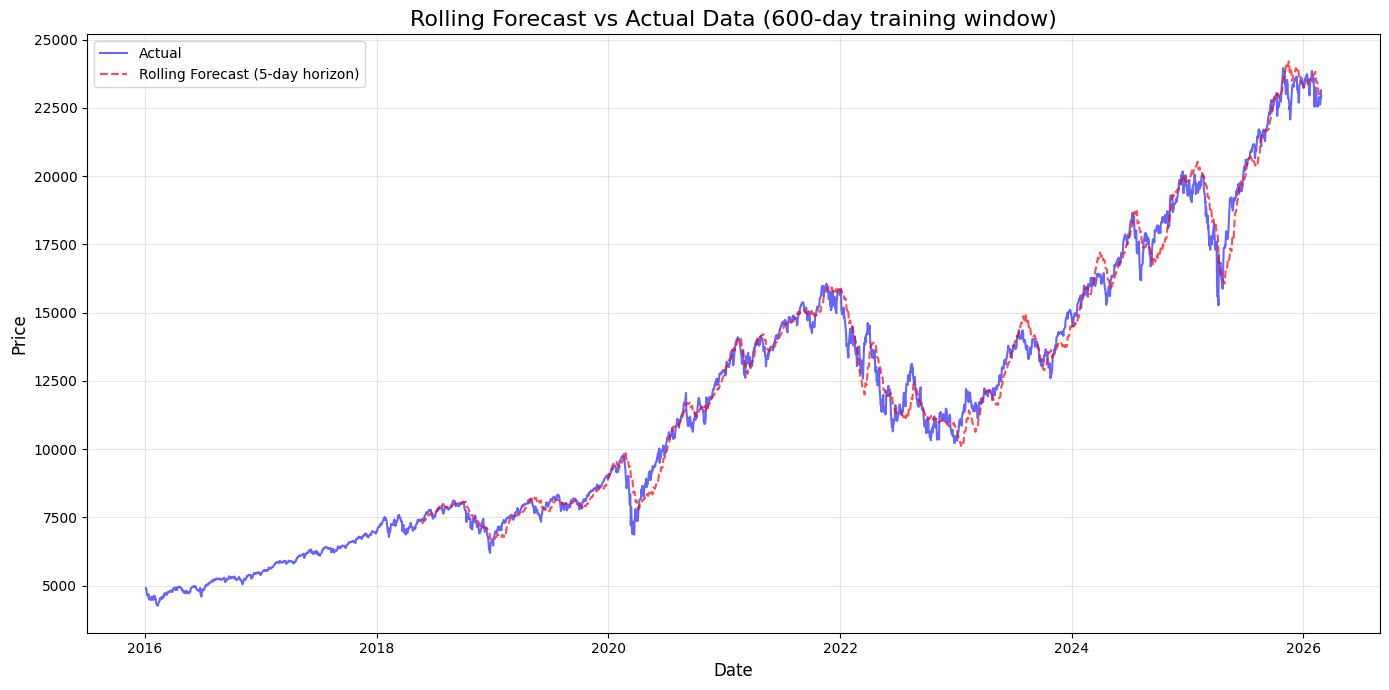

In [67]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))


plt.plot(rolling_df['ds'], rolling_df['y'], label='Actual', color='blue', alpha=0.6)


plt.plot(rolling_forecast_results['ds'], rolling_forecast_results['yhat'],
         label='Rolling Forecast (5-day horizon)', color='red', alpha=0.7, linestyle='--')

plt.title('Rolling Forecast vs Actual Data (600-day training window)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [68]:
comparison_df = pd.DataFrame({
    'Actual': aligned_test['price'],
    'Predicted': aligned_forecast['yhat'],
    'Difference': aligned_test['price'] - aligned_forecast['yhat'],
    'Error (%)': (np.abs(aligned_test['price'] - aligned_forecast['yhat']) / aligned_test['price']) * 100
})

print("Comparison of Actual vs Predicted Values (First 10 rows):")
display(comparison_df.head(10))

print("\nComparison of Actual vs Predicted Values (Last 10 rows):")
display(comparison_df.tail(10))

Comparison of Actual vs Predicted Values (First 10 rows):


,Actual,Predicted,Difference,Error (%)
Date,,,,
2024-02-13,15655.599609,14752.572421,903.027189,5.768078
2024-02-14,15859.150391,14748.283338,1110.867052,7.004581
2024-02-15,15906.169922,14742.007422,1164.162500,7.318937
2024-02-16,15775.650391,14733.843073,1041.807317,6.603895
2024-02-20,15630.780273,14685.159463,945.620810,6.049735
2024-02-21,15580.870117,14669.882157,910.987960,5.846836
2024-02-22,16041.620117,14653.779048,1387.841069,8.651502
2024-02-23,15996.820312,14637.077139,1359.743174,8.500084
2024-02-26,15976.250000,14585.698860,1390.551140,8.703864



Comparison of Actual vs Predicted Values (Last 10 rows):


,Actual,Predicted,Difference,Error (%)
Date,,,,
2025-06-23,19630.970703,17983.087017,1647.883686,8.394306
2025-06-24,19912.529297,17990.919468,1921.609829,9.650255
2025-06-25,19973.550781,17999.503975,1974.046806,9.883304
2025-06-26,20167.910156,18008.939005,2158.971152,10.704982
2025-06-27,20273.460938,18019.305182,2254.155755,11.118752
2025-06-30,20369.730469,18056.500602,2313.229866,11.356212
2025-07-01,20202.890625,18070.996521,2131.894104,10.552421
2025-07-02,20393.130859,18086.520070,2306.610790,11.310724
2025-07-03,20601.099609,18103.026754,2498.072856,12.125920


In [69]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np

performance_df = pd.merge(rolling_forecast_results, rolling_df, on='ds', how='inner', suffixes=('_pred', '_actual'))

print("Merged DataFrame shape:", performance_df.shape)

if not performance_df.empty:
    y_true_rolling = performance_df['y']
    y_pred_rolling = performance_df['yhat']

    mae_rolling = mean_absolute_error(y_true_rolling, y_pred_rolling)
    rmse_rolling = np.sqrt(mean_squared_error(y_true_rolling, y_pred_rolling))
    mape_rolling = mean_absolute_percentage_error(y_true_rolling, y_pred_rolling) * 100

    print(f"Rolling Forecast MAE: {mae_rolling:.2f}")
    print(f"Rolling Forecast RMSE: {rmse_rolling:.2f}")
    print(f"Rolling Forecast MAPE: {mape_rolling:.2f}%")

    display(performance_df[['ds', 'y', 'yhat']].head())
else:
    print("No overlapping dates found between forecast and actuals to calculate metrics.")

Merged DataFrame shape: (1212, 5)
Rolling Forecast MAE: 390.27
Rolling Forecast RMSE: 533.82
Rolling Forecast MAPE: 3.03%


,ds,y,yhat
0,2018-05-22,7378.459961,7271.178345
1,2018-05-23,7425.959961,7276.100333
2,2018-05-24,7424.430176,7280.876244
3,2018-05-25,7433.850098,7285.431017
4,2018-05-30,7462.450195,7380.457249


February 2026 Comparison

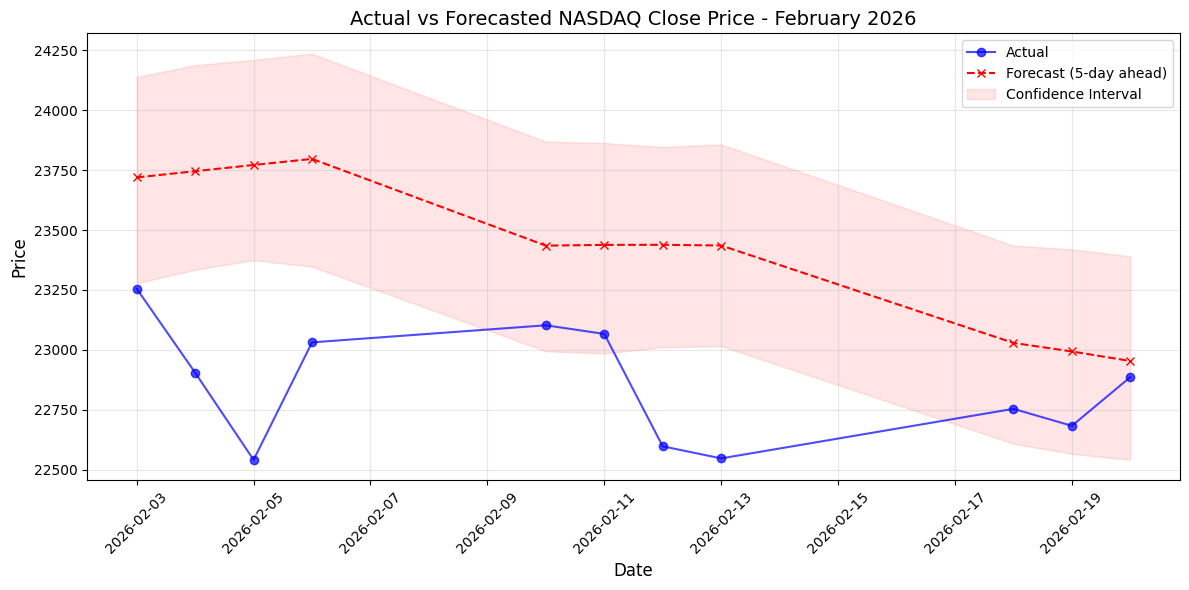

In [70]:
import matplotlib.pyplot as plt

# Filter the performance DataFrame for February 2026
mask_feb_2026 = (performance_df['ds'] >= '2026-02-01') & (performance_df['ds'] <= '2026-02-28')
feb_2026_data = performance_df.loc[mask_feb_2026].sort_values('ds')

if not feb_2026_data.empty:
    plt.figure(figsize=(12, 6))

    # Plot Actual Data
    plt.plot(feb_2026_data['ds'], feb_2026_data['y'],
             label='Actual', marker='o', color='blue', alpha=0.7)

    # Plot Forecast Data
    plt.plot(feb_2026_data['ds'], feb_2026_data['yhat'],
             label='Forecast (5-day ahead)', marker='x', linestyle='--', color='red')

    # Plot Confidence Intervals
    plt.fill_between(feb_2026_data['ds'],
                     feb_2026_data['yhat_lower'],
                     feb_2026_data['yhat_upper'],
                     color='red', alpha=0.1, label='Confidence Interval')

    plt.title('Actual vs Forecasted NASDAQ Close Price - February 2026', fontsize=14)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Price', fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("No overlapping forecast and actual data found for February 2026.")